**Importing Libraries**

In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score

**Importing Dataset**

In [85]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train (2).csv


**Load Dataset**

In [135]:
df= pd.read_csv('.../data/train.csv')

In [136]:
df1 = df.copy()
df2 = df.copy()

In [137]:
df1

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [138]:
#First 5 rows
df1.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [139]:
#Dataset Information
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [140]:
#Missing Values
df1.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


**Exploratory Data Analysis**

**Survival Prediction**

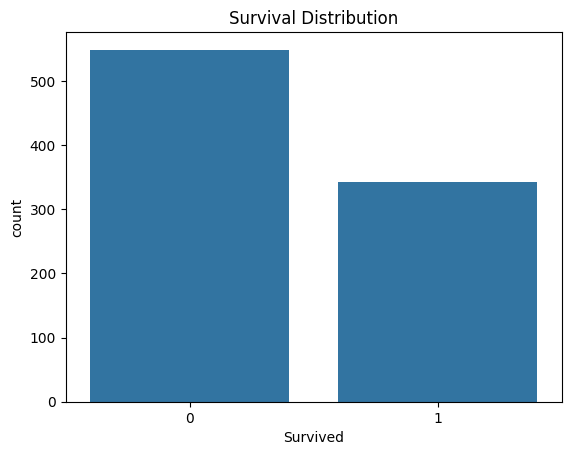

In [141]:
sns.countplot(x='Survived', data=df1)

plt.title('Survival Distribution')
plt.savefig('Survival Distribution.png', bbox_inches='tight', facecolor='white', dpi=150)
plt.show()

**Gender vs. Survival**

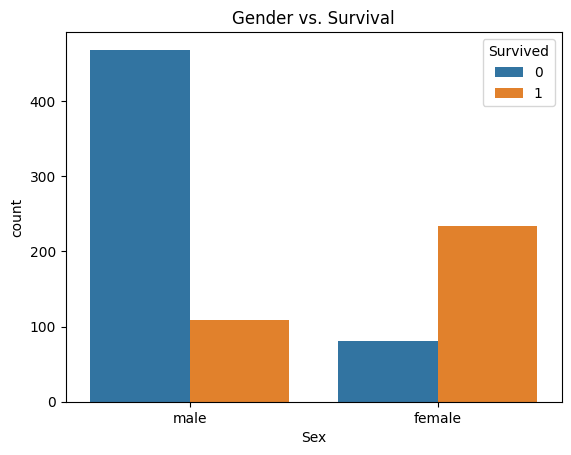

In [142]:
sns.countplot(x='Sex', hue='Survived', data=df1)
plt.title('Gender vs. Survival')
plt.savefig('Gender vs Survival', bbox_inches='tight', facecolor='white', dpi=150)
plt.show()

**Passenger Class vs Survival**

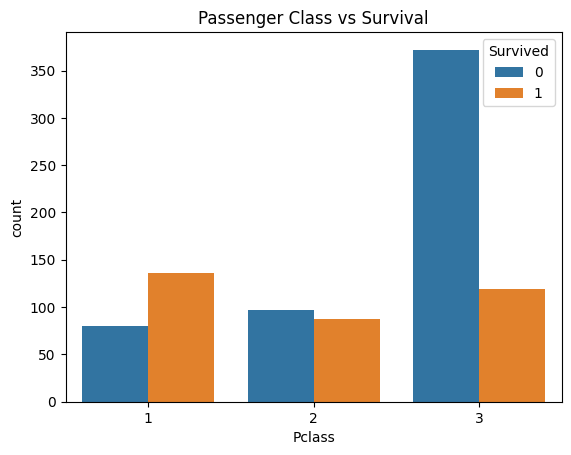

In [143]:
sns.countplot(x='Pclass', hue='Survived', data=df1)
plt.title("Passenger Class vs Survival")
plt.savefig('Passenger Class vs Survival')
plt.show()

**Missing Values Heatmap**

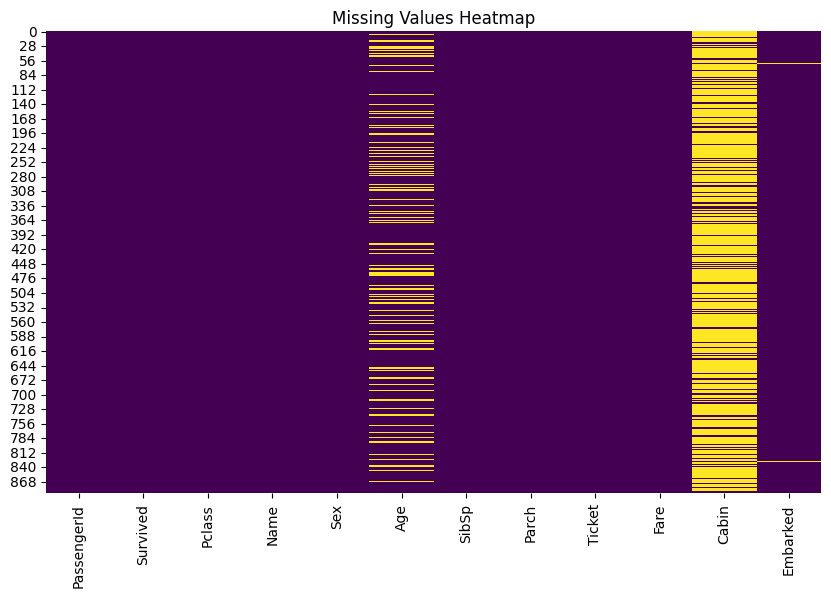

In [144]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    df1.isnull(), cbar=False,
    cmap='viridis'
)

plt.title('Missing Values Heatmap')
plt.savefig('Missing Values Heatmap', bbox_inches='tight', facecolor='white', dpi=150)
plt.show()

**Data Cleaning**



In [145]:
#Fill Missing Age
df1['Age'].fillna(df1['Age'].median(), inplace=True)

/tmp/ipykernel_2987/1752655993.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df1['Age'].fillna(df1['Age'].median(), inplace=True)


In [146]:
#Fill Missing Embarked
df1['Embarked'].fillna(
    df1['Embarked'].mode()[0],
    inplace=True
)

/tmp/ipykernel_2987/2484055807.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df1['Embarked'].fillna(


In [147]:
#Drop Unnecessary Columns
df1.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)

In [148]:
#Verify Missing Values
print(df1.isnull().sum())

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


**Feature Engineering**

**Convert Categorical Variables**

In [149]:
#One-Hot Encoding
df1 = pd.get_dummies(df1, columns=['Sex', 'Embarked'], drop_first=True)

In [150]:
#Check Dataset
df1.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


**Feature & Target Selection**

In [151]:
#Features(X)
X = df1.drop(
    'Survived', axis=1
)
#Target (y)
y = df1['Survived']
#Train_Test_Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Train Logistic Regression**

In [152]:
Ir_model = LogisticRegression(
    max_iter=1000
)

Ir_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [153]:
#predictions
y_pred = Ir_model.predict(X_test)

**Evaluation**

In [154]:
#Accuracy
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.8100558659217877

In [155]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[90, 15],
       [19, 55]])

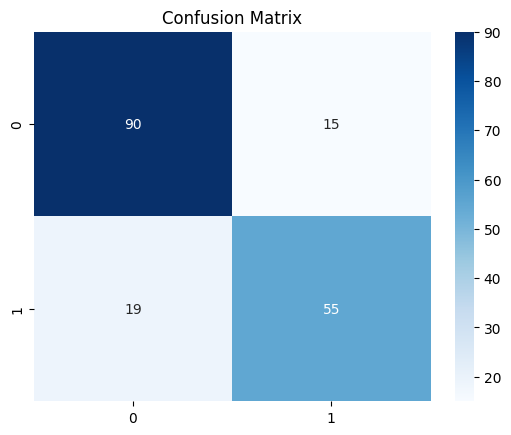

In [156]:
#Visualisation
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.savefig('Confusion Matrix.png', bbox_inches='tight', facecolor='white', dpi=150)
plt.show()

In [157]:
#Precision

precision = precision_score(y_test, y_pred)
print("Precision:", precision)

Precision: 0.7857142857142857


In [158]:
#recall
recall = recall_score(y_test, y_pred)
recall

0.7432432432432432

In [159]:
#F1 Score
f1 = f1_score(y_test, y_pred)
f1

0.7638888888888888

In [160]:
#Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [161]:
#Decision Tree Classifier
dt_model = DecisionTreeClassifier(
    random_state=42,
)

dt_model.fit(
    X_train, y_train
)
dt_pred = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:",dt_accuracy )

Decision Tree Accuracy: 0.7821229050279329


In [162]:
#Random Forest Classifer
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy )

Random Forest Accuracy: 0.8212290502793296


In [163]:
#Compare Models

results = pd.DataFrame({
    'Model':[
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],

    'Accuracy':[
        accuracy,
        dt_accuracy,
        rf_accuracy
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression  0.810056
1        Decision Tree  0.782123
2        Random Forest  0.821229


In [164]:
#Best Model

best_model = results.loc[
    results['Accuracy'].idxmax()
]

print(best_model)

Model       Random Forest
Accuracy         0.821229
Name: 2, dtype: object
